# **1**


El método bootstrap es una técnica de remuestreo que consiste en generar muchas “nuevas” muestras a partir de una muestra original, tomando observaciones con reemplazo.
En cada remuestra se vuelve a calcular el estimador que nos interesa (media, mediana, accuracy, etc.).

# **2**

## Importación de los datos:

LIBRERIAS




In [ ]:

# Librerías base
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Modelado y ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)



CARGA DEL DATASET MEDIANTE LA UNIDAD DE DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Pye/train.csv')
df.head()


Mounted at /content/drive


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Exploración y análisis de los datos

In [ ]:
# Informacion del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Distribución de la variable objetivo (0 no sobrevivio y 1 si sobrevivio)
df['Survived'].value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


VER VALORES FALTANTES

In [ ]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


COMPLETAMOS LOS VALORES FALTANTES DEL DATASET USANDO LA IMPUTACION DE DATOS.

En el caso de la edad usamos la mediana, para puerto la moda y cabina no lo usamos para entrenar el modelo debido a la cantidad de valores faltantes

In [ ]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


/tmp/ipython-input-1413761131.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipython-input-1413761131.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

VERIFICACION DE LA IMPUTACION

In [ ]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


TRANSFORMAMOS LA COLUMNA Sex a Num

In [ ]:
X = df[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']].copy()
y = df['Survived']

X.loc[:, 'Sex'] = X['Sex'].map({'male': 0, 'female': 1})

print("Primeras filas de X con 'Sex' codificado:")
display(X.head())

Primeras filas de X con 'Sex' codificado:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,S
1,1,1,38.0,1,0,71.2833,C
2,3,1,26.0,0,0,7.9250,S
3,1,1,35.0,1,0,53.1000,S
4,3,0,35.0,0,0,8.0500,S


PONEMOS EN UNA VARIABLE PPREDICTORAS EN X Y LA VARIABLE OBJETIVO EN Y

Dejamos afuera columnas como ticket, cabina y nombre, para que no molesten en el momento de entrenar el modelo

In [ ]:
print("Primeras filas de X (variables predictoras):")
display(X.head())

print("\nPrimeras filas de y (variable objetivo):")
display(y.head())


Primeras filas de X (variables predictoras):


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,S
1,1,1,38.0,1,0,71.2833,C
2,3,1,26.0,0,0,7.9250,S
3,1,1,35.0,1,0,53.1000,S
4,3,0,35.0,0,0,8.0500,S



Primeras filas de y (variable objetivo):


,Survived
0,0
1,1
2,1
3,1
4,0


### Ajuste de las variables categóricas y numéricas

Ahora, 'Sex' se ha convertido en una variable numérica. De `variables_categoricas` pasa a `variables_numericas`.

In [ ]:
variables_categoricas = ['Embarked']
variables_numericas = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex'] # 'Sex' se añade a las numéricas

print("Nuevas variables categóricas:", variables_categoricas)
print("Nuevas variables numéricas:", variables_numericas)

Nuevas variables categóricas: ['Embarked']
Nuevas variables numéricas: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex']


### Recreación del preprocesador con los ajustes

Ahora recrearemos el `ColumnTransformer` con la configuración actualizada.

In [ ]:
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), variables_categoricas)
    ]
)

# **3**

## *ESTIMADORES ESTADÍSTICOS*

In [ ]:
# Estimador 1: Diferencia de Medias (Fare entre supervivientes y no supervivientes)
fare_survived = df[df['Survived'] == 1]['Fare'].mean()
fare_not_survived = df[df['Survived'] == 0]['Fare'].mean()
estimador_1 = fare_survived - fare_not_survived

print(f"Estimador 1 (Diferencia de media de Fare): {estimador_1:.2f}")

Estimador 1 (Diferencia de media de Fare): 26.28


In [ ]:
# Estimador 2: Coeficiente de correlación entre Age y Fare
# Aseguramos que no haya NaNs en Age o Fare antes de calcular la correlación, aunque Age ya fue imputado.
estimador_2 = df[['Age', 'Fare']].corr().loc['Age', 'Fare']

print(f"Estimador 2 (Correlación entre Age y Fare): {estimador_2:.2f}")

Estimador 2 (Correlación entre Age y Fare): 0.10


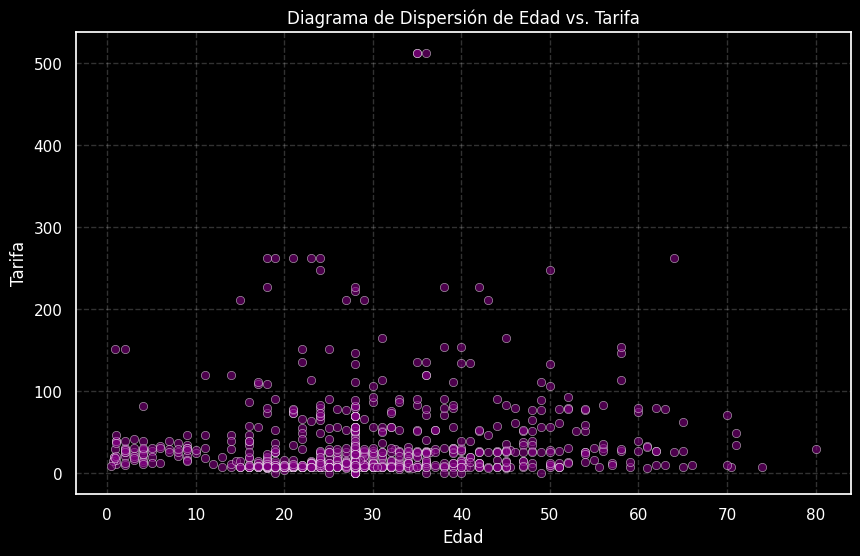

In [ ]:
plt.style.use('dark_background')

plt.figure(figsize=(10, 6))

sns.scatterplot(x='Age', y='Fare', data=df, color='purple', alpha=0.6)

plt.title('Diagrama de Dispersión de Edad vs. Tarifa', color='white')
plt.xlabel('Edad', color='white')
plt.ylabel('Tarifa', color='white')

plt.tick_params(axis='x', colors='white')
plt.tick_params(axis='y', colors='white')

plt.grid(True, linestyle='--', alpha=0.2)
plt.show()

## *REGRESIÓN LOGÍSITICA*

Utilizamos como estimador principal 'accuaracy', obtenido al aplicar un modelo de regresión lineal en la muestra original.

DIVIDIMOS MODELO TEST Y ENTRENAMIENTO

In [ ]:
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y # stratify=y para mantener la proporción de sobrevivientes
)

print("Tamaño de entrenamiento:", X_entrenamiento.shape)
print("Tamaño de prueba:", X_prueba.shape)

Tamaño de entrenamiento: (623, 7)
Tamaño de prueba: (268, 7)


CREAMOS EL PIPELINE COMPLETO AGREGANDO EL MODELO DE REGRESION LOGISTICA

In [ ]:
modelo_base = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('clasificador', LogisticRegression(max_iter=200))
])

ENTRENAMOS MODELO

In [ ]:
modelo_base.fit(X_entrenamiento, y_entrenamiento)
print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


HACEMOS PREDICCIONES Y OBTENEMOS PROBABILIDADES

In [ ]:
y_pred = modelo_base.predict(X_prueba)

y_prob = modelo_base.predict_proba(X_prueba)[:, 1]

METRICAS DEL MODELO (LA QUE USAREMOS PARA BOOSTSTRAP)

In [ ]:

accuracy = accuracy_score(y_prueba, y_pred)
f1 = f1_score(y_prueba, y_pred)

print("Accuracy del modelo base:", accuracy)
print("F1-score del modelo base:", f1)

Accuracy del modelo base: 0.7985074626865671
F1-score del modelo base: 0.7352941176470589


MATRIZ DE CONFUSION

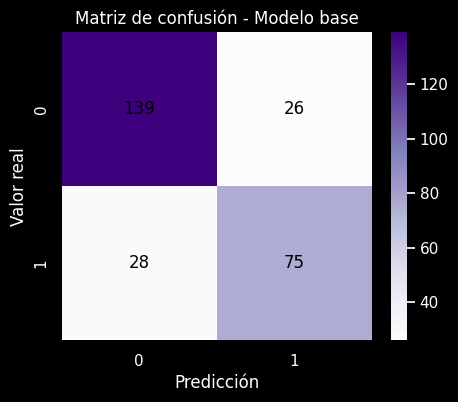

In [ ]:
cm = confusion_matrix(y_prueba, y_pred)

# Configura el estilo de matplotlib para fondo negro y texto blanco
plt.style.use('dark_background')

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            annot_kws={"color": "black"}) # Asegura que el texto sea blanco

plt.title("Matriz de confusión - Modelo base", color="white")
plt.xlabel("Predicción", color="white")
plt.ylabel("Valor real", color="white")

# Asegúrate de que los ticks también sean blancos si el estilo 'dark_background' no lo hace por completo
plt.tick_params(axis='x', colors='white')
plt.tick_params(axis='y', colors='white')

plt.show()

REPORTE COMPLETO DEL CLASIFICADOR

In [ ]:
print(classification_report(y_prueba, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.84      0.84       165
           1       0.74      0.73      0.74       103

    accuracy                           0.80       268
   macro avg       0.79      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268



In [ ]:

nombres_variables = modelo_base.named_steps['preprocesamiento'].get_feature_names_out()

coeficientes = modelo_base.named_steps['clasificador'].coef_[0]
intercepto = modelo_base.named_steps['clasificador'].intercept_[0]

tabla_pesos = pd.DataFrame({
    'Variable': nombres_variables,
    'Peso (Beta)': coeficientes
}).sort_values(by='Peso (Beta)', ascending=False) # Ordenamos de mayor a menor importancia

print(f"Intercepto (Ordenada al origen): {intercepto:.4f}")
print("\n--- TABLA DE COEFICIENTES DEL MODELO ---")
print(tabla_pesos)

Intercepto (Ordenada al origen): -0.3742

--- TABLA DE COEFICIENTES DEL MODELO ---
          Variable  Peso (Beta)
5         num__Sex     1.260175
7  cat__Embarked_Q     0.461652
3       num__Parch     0.069371
4        num__Fare     0.063430
6  cat__Embarked_C    -0.136592
8  cat__Embarked_S    -0.322342
1         num__Age    -0.361936
2       num__SibSp    -0.390413
0      num__Pclass    -1.061973


# **5**

## *BOOTSTRAP PARA ESTIMADOR 1 (Diferencia de Medias)*
Aplicamos el método bootstrap para estimar la diferencia de medias de 'Fare' entre supervivientes y no supervivientes, generando remuestras y calculando el estimador en cada una.

In [ ]:
B = 1000
fare_diffs_bootstrap = []

print(f"Cantidad de remuestras bootstrap (B): {B}")

Cantidad de remuestras bootstrap (B): 1000


A continuación se implementa el loop de Bootstrap para generar remuestras del DataFrame original, se calcula la diferencia de la media de 'Fare' para sobrevivientes y no sobrvivientes para cada remuestreo y se guardan en 'fare_diffs_bootstrap'

In [ ]:
from sklearn.utils import resample

for i in range(B):
    # Crear una muestra bootstrap del DataFrame df
    # Asegurarse de que 'Survived' y 'Fare' estén en la muestra bootstrapped
    boot_sample = resample(df, replace=True, random_state=i)

    # Calcular la media de 'Fare' para supervivientes y no supervivientes en la muestra bootstrap
    fare_survived_boot = boot_sample[boot_sample['Survived'] == 1]['Fare'].mean()
    fare_not_survived_boot = boot_sample[boot_sample['Survived'] == 0]['Fare'].mean()

    # Calcular la diferencia entre estas dos medias
    diff_boot = fare_survived_boot - fare_not_survived_boot

    # Añadir esta diferencia a la lista
    fare_diffs_bootstrap.append(diff_boot)

print(f"Loop de Bootsrap completado. {len(fare_diffs_bootstrap)} Diferencias calculadas.")

Loop de Bootsrap completado. 1000 Diferencias calculadas.


Una vez completados los procesos de remuestreo y el cálculo de diferencias, calculamos la media y un intervalo de confianza del 95% para estos estimadores del bootstrap.

In [ ]:
fare_diffs_bootstrap = np.array(fare_diffs_bootstrap)

media_diff_bootstrap = fare_diffs_bootstrap.mean()
ic_inf_diff = np.percentile(fare_diffs_bootstrap, 2.5)
ic_sup_diff = np.percentile(fare_diffs_bootstrap, 97.5)

print(f"Media bootstrap de la diferencia de Fare: {media_diff_bootstrap:.2f}")
print(f"IC 95% para la diferencia de Fare: ({ic_inf_diff:.2f}, {ic_sup_diff:.2f})")

Media bootstrap de la diferencia de Fare: 26.08
IC 95% para la diferencia de Fare: (19.03, 33.75)


GRÁFICO DE DISTRIBUCIÓN DE BOOTSTRAP

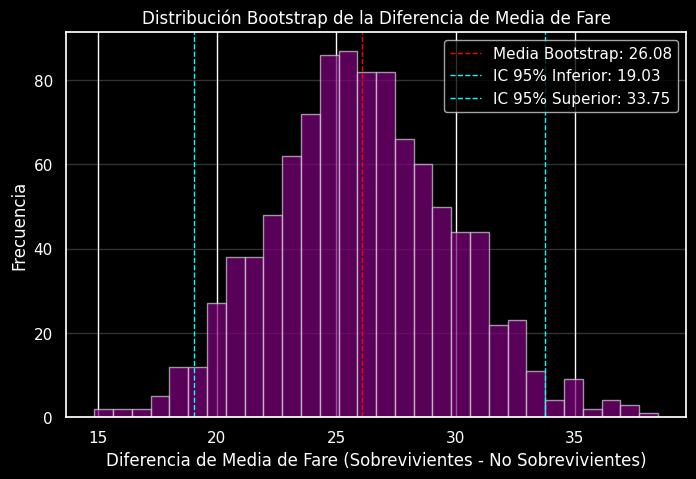

In [ ]:
plt.style.use('dark_background')

plt.figure(figsize=(8, 5))

# Cambia el color de las barras a morado ('purple')
# Cambia el 'edgecolor' de 'black' a 'lightgray' para que sea visible
plt.hist(fare_diffs_bootstrap, bins=30, color='purple', edgecolor='lightgray', alpha=0.7)

# El estilo 'dark_background' se encarga de que el texto sea blanco
plt.title('Distribución Bootstrap de la Diferencia de Media de Fare')
plt.xlabel('Diferencia de Media de Fare (Sobrevivientes - No Sobrevivientes)')
plt.ylabel('Frecuencia')

# Las líneas de colores (rojo, verde) resaltarán bien sobre el fondo oscuro
plt.axvline(media_diff_bootstrap, color='red', linestyle='dashed', linewidth=1, label=f'Media Bootstrap: {media_diff_bootstrap:.2f}')
plt.axvline(ic_inf_diff, color='cyan', linestyle='dashed', linewidth=1, label=f'IC 95% Inferior: {ic_inf_diff:.2f}') # 'cyan' para mejor contraste
plt.axvline(ic_sup_diff, color='cyan', linestyle='dashed', linewidth=1, label=f'IC 95% Superior: {ic_sup_diff:.2f}') # 'cyan' para mejor contraste

# La leyenda se adaptará automáticamente al fondo oscuro
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.show()

**RESUMEN**

Para el estimador de Diferencias de Medias para 'Fare' entre sobrevivientes y no-sobrevivientes:


*   La media que se obtuvo mediante la aplicación de bootstrap en 'Fare' fue de aproximadamente $26.08.

*   El Intervalo de Confianza del 95% para esta diferencia fue (\$19.03, \$33.75)

*   El rango positivo del intervalo de confianza sugiere que, en promedio, los sobrevivientes pagaron una cantidad significantemente más grande en sus tarifas que los no-sobrevivientes. La visualización de la distribución mostraría esta tendencia central y dispersión.





## *BOOTSTRAP PARA ESTIMADOR 2* (Correlación Age y Fare)

Aplicamos el método bootstrap para estimar el coeficiente de correlación entre 'Age' y 'Fare', generando remuestras, calculando el estimador en cada una, y almacenando los resultados.


In [ ]:
B = 1000
age_fare_correlations_bootstrap = []

print(f"Cantidad de remuestras bootstrap (B): {B}")

Cantidad de remuestras bootstrap (B): 1000


A continuación se implementa el loop de Bootstrap para generar remuestras del DataFrame original, se calcula el coeficiente de correlación Pearson entre 'Age' y 'Fare' para cada remuestreo y se guardan en 'age_fare_correlations_bootstrap'

In [ ]:
for i in range(B):
    # Crear una muestra bootstrap del DataFrame df
    boot_sample = resample(df, replace=True, random_state=i)

    # Calcular el coeficiente de correlación entre 'Age' y 'Fare' en la muestra bootstrap
    # Aseguramos que no haya NaNs antes de calcular la correlación para la muestra bootstrapped
    # Aunque Age y Embarked ya han sido imputados en el df original, una muestra bootstrap
    # podría teóricamente generar un subconjunto con NaN si no se manejaran previamente,
    # pero dado el estado actual de df, 'Age' no tendrá NaNs. 'Fare' no tiene NaNs.
    corr_boot = boot_sample[['Age', 'Fare']].corr().loc['Age', 'Fare']

    # Añadir esta correlación a la lista
    age_fare_correlations_bootstrap.append(corr_boot)

print(f"Bootstrap loop completed. {len(age_fare_correlations_bootstrap)} correlations calculated.")

Bootstrap loop completed. 1000 correlations calculated.


Una vez completados los procesos de remuestreo y el cálculo de diferencias, calculamos la media y un intervalo de confianza del 95% para estos estimadores del bootstrap.

In [ ]:
age_fare_correlations_bootstrap = np.array(age_fare_correlations_bootstrap)

media_corr_bootstrap = age_fare_correlations_bootstrap.mean()
ic_inf_corr = np.percentile(age_fare_correlations_bootstrap, 2.5)
ic_sup_corr = np.percentile(age_fare_correlations_bootstrap, 97.5)

print(f"Media bootstrap del coeficiente de correlación (Age y Fare): {media_corr_bootstrap:.4f}")
print(f"IC 95% para el coeficiente de correlación: ({ic_inf_corr:.4f}, {ic_sup_corr:.4f})")

Media bootstrap del coeficiente de correlación (Age y Fare): 0.0968
IC 95% para el coeficiente de correlación: (0.0444, 0.1556)


GRÁFICO DE DISTRIBUCIÓN DE BOOTSTRAP

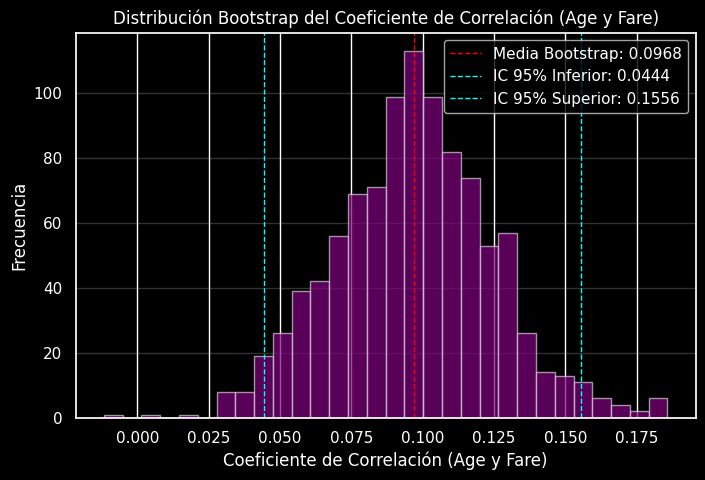

In [ ]:
plt.style.use('dark_background')

plt.figure(figsize=(8, 5))

# Cambia el color de las barras a morado ('purple')
# Cambia el 'edgecolor' de 'black' a 'lightgray' para que sea visible
plt.hist(age_fare_correlations_bootstrap, bins=30, color='purple', edgecolor='lightgray', alpha=0.7)

# El estilo 'dark_background' se encarga de que el texto sea blanco
plt.title('Distribución Bootstrap del Coeficiente de Correlación (Age y Fare)')
plt.xlabel('Coeficiente de Correlación (Age y Fare)')
plt.ylabel('Frecuencia')

# Las líneas de colores (rojo, verde) resaltarán bien sobre el fondo oscuro
plt.axvline(media_corr_bootstrap, color='red', linestyle='dashed', linewidth=1, label=f'Media Bootstrap: {media_corr_bootstrap:.4f}')
plt.axvline(ic_inf_corr, color='cyan', linestyle='dashed', linewidth=1, label=f'IC 95% Inferior: {ic_inf_corr:.4f}') # 'cyan' para mejor contraste
plt.axvline(ic_sup_corr, color='cyan', linestyle='dashed', linewidth=1, label=f'IC 95% Superior: {ic_sup_corr:.4f}') # 'cyan' para mejor contraste

# La leyenda se adaptará automáticamente al fondo oscuro
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.show()

**RESUMEN**

Para el estimador de Correlación entre 'Age' [Edad] y 'Fare' [Tarifa]:


*   Media: El coeficiente de correlación medio del bootstrap entre 'Age' y 'Fare' fue de aproximadamente 0.0968.

*   Intervalo de Confianza: El intervalo de confianza del 95% para esta correlación fue (0.0444, 0.1556).

*   Los pequeños valores positivos dentro del intervalo de confianza indican una correlación débil pero consistentemente positiva entre la edad y la tarifa, sugiriendo que los pasajeros mayores podrían tener tarifas ligeramente más altas, aunque la relación no es fuerte.


## *BOOTSRAP PARA MODELO DE REGRESIÓN LINEAL*

BUCLE DE BOOTSTRAP TRABAJANDO CON ACCURACY - BOOTSTRAP INTEGRADO A UN MODELO DE IA

In [ ]:
B = 1000
accuracy_bootstrap = []

for i in range(B):
    # Crear una muestra bootstrap del conjunto de entrenamiento
    X_boot, y_boot = resample(X_entrenamiento, y_entrenamiento,
                              replace=True, random_state=i)

    # Entrenar el modelo en la muestra bootstrap
    modelo_base.fit(X_boot, y_boot)

    # Predicción en el conjunto de prueba (el test se mantiene fijo)
    y_pred_boot = modelo_base.predict(X_prueba)

    # Calcular accuracy
    acc_boot = accuracy_score(y_prueba, y_pred_boot)
    accuracy_bootstrap.append(acc_boot)

print(f"Loop de bootstrap completado. {len(accuracy_bootstrap)} accuracies calculados.")


Loop de bootstrap completado. 1000 accuracies calculados.


ESTADISTICAS DEL BOOTSTRAP

In [ ]:
accuracy_bootstrap = np.array(accuracy_bootstrap)

media_acc_bootstrap = accuracy_bootstrap.mean()
ic_inf_acc = np.percentile(accuracy_bootstrap, 2.5)
ic_sup_acc = np.percentile(accuracy_bootstrap, 97.5)

print(f"Media bootstrap del accuracy: {media_acc_bootstrap:.4f}")
print(f"IC 95% del accuracy: ({ic_inf_acc:.4f}, {ic_sup_acc:.4f})")


Media bootstrap del accuracy: 0.7963
IC 95% del accuracy: (0.7799, 0.8098)


GRAFICO DE LA DISTRIBUCION

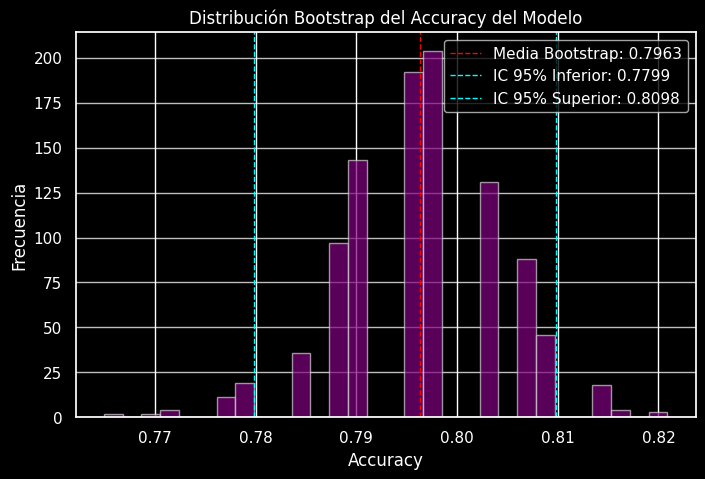

In [ ]:
plt.style.use('dark_background')

plt.figure(figsize=(8, 5))

# Cambia el color de las barras a morado ('purple')
# Cambia el 'edgecolor' de 'black' a 'lightgray' para que sea visible
plt.hist(accuracy_bootstrap, bins=30, color='purple', edgecolor='lightgray', alpha=0.7)

# El estilo 'dark_background' se encarga de que el texto sea blanco
plt.title('Distribución Bootstrap del Accuracy del Modelo')
plt.xlabel('Accuracy')
plt.ylabel('Frecuencia')

# Las líneas de colores (rojo, verde) resaltarán bien sobre el fondo oscuro
plt.axvline(media_acc_bootstrap, color='red', linestyle='dashed', linewidth=1, label=f'Media Bootstrap: {media_acc_bootstrap:.4f}')
plt.axvline(ic_inf_acc, color='cyan', linestyle='dashed', linewidth=1, label=f'IC 95% Inferior: {ic_inf_acc:.4f}') # 'cyan' para mejor contraste
plt.axvline(ic_sup_acc, color='cyan', linestyle='dashed', linewidth=1, label=f'IC 95% Superior: {ic_sup_acc:.4f}') # 'cyan' para mejor contraste

# La leyenda se adaptará automáticamente al fondo oscuro
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

**INTERPRETACION DE LA DSITRIBUCION:**

Al aplicar 1000 remuestras bootstrap, obtuvimos la distribución del accuracy mostrada en la Figura anterior.
La mayor parte de los valores se encuentran entre 0.79 y 0.81, lo que indica que el modelo tiende a mantener un rendimiento estable independientemente de pequeñas variaciones en los datos de entrenamiento.
Solo unas pocas remuestras generaron accuracies más bajos (≈0.77), lo cual muestra que existe cierta variabilidad, pero no extrema.
Esta distribución permite estimar un intervalo de confianza para el accuracy del modelo, reflejando la incertidumbre asociada a su desempeño real.